# VaLPAS prototype
VaLPAS (***Va***riation-***L***everaged ***P***henomic ***A***ssoccioation ***S***tudy) is a toolkit with the ultimate purpose to iluminate the biological dark matter by providing a systemic framework to predict protein functionality from phenomics. VaLPAS uses phenotypic variation between organisms as well as various modes of omics-data (e.g. Proteomics, Metabolomics, Transcriptomics, etc.) collected under differing environmental conditions. The toolkit generates associations between the different datatypes that then can be leveraged to postulate hypothesis of protein functionality for proteins of previously unknown function.

VaLPAS (`valpas.py`) can be either executed from the command line once the toolkit is installed or be used from within a Jupyter Notebook (like this one) by invoking internal functions. Currently VaLPAS' two main subroutines (commands) are to:
- generate said associations (`associate`)
- visualize association strenghts for further investigation (`visualize`)

## Dependencies
Dependencies to run this notebook should be installed according to the README.md located at the root folder of the project. Generally it is advised to cerate a `conda` environment using the provided `environment.yml`.

### Jupyter notebook "frontmatter"
The following lines of code are overhead to make loading of the valpas package possible from within the notebook without having to install the package via pip / setuptools. Essentially this loads the 'src/' folder into the sys path as searchable for modules. 

In [1]:
# iPython magic to autoreload modules everytime code is executed to propagate changes to the code
%load_ext autoreload
%autoreload 2

# loading '/src' into sys path
import os
import sys
import valpas

# don't show warnings
import warnings
warnings.filterwarnings('ignore')

### Defining the file path to the sample files
Below we will be defining some file paths to sample files that will be used for this tutorial / notebook. Note that the two csv files contain the same information as the xlsx file and are interchangeable. We define all three such that we can demonstrate the ability to import from both csv and xlsx files.

Furthemore we define outfile paths to three different outfiles:
- Metabolite vs. Metabolite association list in CSV format
- Metabolite vs. Protein association matrix in CSV format
- XLSX file that will host multiple sheets containing various combinations of results

In [2]:
# path to the csv containing the proteome data
fpath_prot_csv = os.path.join(
    os.getcwd(),
    "..",
    "sample_data",
    "in_test_data",
    "rhodo_test_data__proteomics.csv"
    )

# path to the csv containing the metabolomics data
fpath_metabol_csv = os.path.join(
    os.getcwd(),
    "..",
    "sample_data",
    "in_test_data",
    "rhodo_test_data__metabolomics.csv"
    )

# path to the excel file containing both the proteomics and metabolomics data
fpath_input_xlsx = os.path.join(
    os.getcwd(),
    "..",
    "sample_data",
    "in_test_data",
    "rhodo_test_data.xlsx"
)

# path to the folder that contains all test input files
path_infiles_folder = os.path.join(
    os.getcwd(),
    '..',
    'sample_data',
    'in_test_data'
)

# path to the csv and excel outfiles
fpath_output_assoc_list_csv = os.path.join(
    os.getcwd(),
    "..",
    "sample_data",
    "out",
    "rhodo_test_metabol-metabol_assoc_list.csv"
)
fpath_output_assoc_mat_csv = os.path.join(
    os.getcwd(),
    "..",
    "sample_data",
    "out",
    "rhodo_test_prot-metabol_assoc_mat.csv"
)
fpath_output_xlsx = os.path.join(
    os.getcwd(),
    "..",
    "sample_data",
    "out",
    "rhodo_test_out.xlsx"
)

## Creating associations between omics-data with `valpas.py associate`
The VaLPAS toolkit offers a command line tool to perform all operations. As displayed below (starting a line of code in a Jupyter Notebook cell with `'!'` executes the line on the command line) when executing `valpas.py` without any additional parameters it will return a basic description of the tool including the available subroutines.

In [3]:
! valpas

usage: valpas [-h] {associate,prepare,visualize} ...

VaLPAS is a framework to establish and investigate functional 
relations between proteins and other "omics-data". It currently 
consits of the the two sub routines:

    - associate    (creates associations between data instances)
    - visualize    (helps to visualize generated associations)

options:
  -h, --help            show this help message and exit

commands:
  {associate,prepare,visualize}


Next we will take a look at the available options when running the `associate` subroutine. Note you can also retrieve a more detailed list of command line arguments including a brief description of the arguments by invoking `python valpas.py associate` with the `-h/--help` command. The `associate` command also requires an additional subroutine that defines if the input files that need to be ingested are directly defined (`from_file`) or are retrieved from a defined folder (`from_folder`). Furthermore, the use case between those two options is slightly different, `from_folder` enabeling "Cross-Experiment Associations", something that will be discussed in detail further down the line. For now the focus will be on `valpas.py associate from_file`

In [4]:
! valpas associate from_file

usage: valpas associate from_file [-h]
                                  [-a {spearman,pearson,mutual_information,cosine_similarity,cosine_distance,jaccard_similarity,jaccard_index,jaccard_distance}]
                                  [-o OUTFILE] [-O]
                                  [-ot {sorted_list,correlation_matrix}]
                                  [-f FILTER_CUTOFF] [--csv | --xlsx]
                                  [-s SHEET] [-S SHEET2] -i INFILE
                                  [-I INFILE2]
valpas associate from_file: error: the following arguments are required: -i/--infile


Finally for easier use of valpas within the notebook (e.g. being able to reuse the previously define filepaths) we will import the main function of `valpas.py` and invoke it directly in this notebook. Note that this will technically slightly alter the behaviour of `valpas.py` i.e. internally `ipykernel_launcher.py` is used to run the "main" function which also includes slightly altered error and outstream handling. For the purposes of demonstrating the functionality of the toolkit this will not make a difference however.

We will however have to manually create a system argument variables array (`sys.argv`) that contains all the information we would normally pass to the program on the commandline. More on this further below.

In [5]:
from valpas.cli import main as valpas_main

### Data overview
To understand the data and the structure of the datafiles we will be working with let's take a quick look at one of the sample CSVs. To this end we will import the `pandas` library and simply read the CSV and display it.

In [6]:
import pandas as pd
pd.read_csv(fpath_metabol_csv)


,Metabolite,G_SD_exp,GX_SD_exp,X_SD_exp,X_SD_stat,A_SD_exp,C_SD_exp,C_SD_exp (extracellular)
0,protocatechuic acid,NaN,NaN,NaN,NaN,NaN,128,2975.0
1,"1,3-dihydroxyacetone",725.0,668.0,844.0,450.0,1312.0,5178,NaN
2,2-furoic acid,3.0,2010.0,3348.0,319.0,4.0,0,NaN
3,2-hydroxycinnamic acid,0.0,0.0,0.0,0.0,0.0,588,NaN
4,2-hydroxyglutaric acid,1263.0,2006.0,518.0,155.0,1741.0,1748,NaN


As displayed above, the file consits of several rows of data, each representing omics measures for a specific metabolite. The metabolite is listed in column 1, with each consecutive column listing the experimental condition under which the organism was grown. Each cell in the condition columns contains the measured (for example by mass spectrometry analysis) abundance of the (in this case) metabolite. It is important to not that `0.0` values and `NaN` can be treated interchangeabely, i.e. the metabolite was not detected by the analysis.

### Correlation between samples from one data type
Running `valpas.py associate` with default parameters will create associations by using pearson correlation coefficient (see also `-a/--association_type` in the help output for a full list of association types available). Additionally, at default `-f/--filter_missing_values` will be set to `0.9`. This means that at least 90% of the available conditions that omics measurements have been retrieved from must have reported a value for the specific data point (e.g. metabolite) for it to be considered in the association calculations. As we saw above the sample data contains only a very small number of experimental conditions (columns) as well as metabolites (rows), i.e. one entry per row that is set to `0.0` or `NaN` will be sufficient to exclude said row if `-f` is left at the default value of `0.9`. To this end we need to adjust `-f` to a smaller value. We will be using `-f 0.5` for the remainder of this tutorial. As a final note, once input from two omics datatypes is considered in the calculation of the association values, the algorithm also makes sure that the conditions (columns) match between the two datatypes and excludes any columns that are unique to either datatype. This can lead to an even smaller number of conditions being considered in the association calculation.

For the first demonstration of the tool we will leave every argument at default, with the exception of `-f/--filter_cutoff` for the reasons described above. This will calculate the pearson correlation between instances within one data type, namely the "Metabolomics". The returned list is sorted descending (i.e. stronges correlation first).

The command issued below is equivalent to calling `python valpas.py associate -i INFILE -f 0.5` from the command line, where `INFILE='../sample_data/in_test_data/rhodo_test_data_proteomics.csv'` as defined in [Defining the file path...](#defining-the-file-path-to-the-sample-files).

As previously mentioned we will have to cerate an argument variable list first though. This will be done by manually assigning values to `sys.argv`. Note that `sys.argv[0]` normally is populated by the python script path, hence we need to populate this field with a dummy value here.

If not further defined the script defaults to print the sorted list of id pairs with their association score to `stdout`.

In [7]:
sys.argv = [
    'valpas', # dummy value such that the main / argparse works properly
    'associate',
    'from_file',
    '--csv',
    '-i', fpath_metabol_csv,
    '-f', '0.5'
    ]

valpas_main()

metabolomics_1,metabolomics_2,association,counts
"1,3-dihydroxyacetone",2-hydroxyglutaric acid,0.4037734380145498,6.0
"1,3-dihydroxyacetone",2-furoic acid,-0.11879991955799762,5.0
2-furoic acid,2-hydroxyglutaric acid,-0.13491949792117228,5.0


The resulting output is csv formatted and lists an additional column named `counts` next to the correlation value (`pearson`). This column lists the number of experimental conditions that went into the calculation of the association value the between the two datapoints. For example the correlation between *1,3-dihydroxyacetone* and *2-furoic acid* is based on 5 conditions. Looking this up in the table above we can see that those were the conditions `G_SD_exp`, `GX_SD_exp`, `X_SD_exp`, `X_SD_stat` and `A_SD_exp`. `C_SD_exp` and `C_SD_exp (extracellular)` are not included because in the case of `C_SD_exp (extracellular)` both metabolites did not have a reported value, whereas for `C_SD_exp` only *1,3-dihydroxyacetone* reported a value.

### Correlation between samples from two different data types
Next we calculate the correlation between instances across two different types of data (in this example proteins and metabolites). 

For this example we will import the data from the previously defined Excel file. If we import from Excel files we addtionally need to define the Sheets that should be imported. In this case we will use `-s Metabolomics` and `-S Proteomics`, i.e. importing the data from the sheets `Metabolomics` and `Proteomics` in `'../sample_data/in_test_data/rhodo_test_data.xlsx'`. If we were to omit the argument `-S/--excel_sheet_name_2` from the command, only the sheet defined in `-s/--excel_sheet_name` will be imported and act as sole data source, i.e. the tool would behave just like if we were importing from one CSV file. Note that import from xlsx and csv files can be mixed and matched. For example one datasource could be a CSV and the other one sheet from an Excel file. A second file can be passed to the tool via `-I/--infile2`. Generally we would advise though to either stick to one Excel file and two sheet definitions, or importing from two seperate CSVs. Mixing and matching could lead to unexpected behaviour.

Next, we will define the output format as association matrix. This will print the whole association matrix instead of a sorted list. This can be done via `-ot/--output_type correlation_matrix`. Furthermore, we can select a different association metric that should be used to calculate the association value between datapoints. This is done via the commandline argument `-a/--association_type`. We will select `mutual_information`. Finally, we will also write the output to a local file instead of piping it to stdout. This can be achieved by setting a path to an outfile via `-o/--outfile`. We also continue to use `-f 0.5` for previously detailed reasons.

The resulting (and equivalent) command on the command line would be:
```sh
python valpas.py associate \
    -i ../sample_data/in_test_data/rhodo_test_data.xlsx \
    -s Metabolomics \
    -S Proteomics \
    -ot correlation_matrix \
    -a mutual_information \
    -f 0.5 \
    -o ../sample_data/out/rhodo_test_prot-metabol_assoc_mat.csv \
    -O
```



In [8]:
sys.argv = [
    'valpas',
    'associate',
    'from_file',
    '--xlsx',
    '-i', fpath_input_xlsx,
    '-s', 'Metabolomics',
    '-S', 'Proteomics',
    '-ot', 'correlation_matrix',
    '-a', 'jaccard_index',
    '-f', '0.5',
    '-o', fpath_output_assoc_mat_csv,
    '-O'
    ]
valpas_main()

In [9]:
! cat ../sample_data/out/rhodo_test_prot-metabol_assoc_mat.csv

Metabolomics,"1,3-dihydroxyacetone",2-furoic acid,2-hydroxyglutaric acid
8371,0.0:3.0,0.66667:3.0,0.66667:3.0
8372,1.0:1.0,0.0:2.0,0.25:4.0
8373,0.0:2.0,0.33333:3.0,0.66667:3.0


The resulting association matrix in csv format contains two values per cell separated by ':', i.e. 'association_value':'counts' where the counts variable is the same as described before.

Alternatively it is also possible to export the association matrix to an Excel file, which would result in the creation of two sheets, one containing the association values, the other the counts. Note, that the additional commandline argument `-O/--overwrite_output` can be passed along that will enable 
- the result file to be overwritten if it already exists (in case the result file is a CSV)
- the sheets to be overwritten if already present in the excel sheet (in case the result file is a XLSX)
If `-O` is omitted and the csv or a sheet in the excel file already exists the tool will exit with a error message.

## Visualization with `valpas.py visualize`

We can visualize some of the results using the `visualize` command of `valpas.py`. At this time only heatmap visualization is implemented and only in a very basic form.

Below is a example command to generate a heatmap visualization of the associations generated from the command line using the [previously generated correlation matrix](#correlation-between-samples-from-two-different-data-types) between portein identfiers and metabolites.

First we define some basic file paths and then execute the `valpas.py visualize` subroutine to create a heatmap of the imported correlation matrix.

Note that if executed from the command line the resulting plot will not be directly displayed. An outfile path for the graphic **has to be defined** otherwise the graphic will be lost. Executing the command in a Jupyter Notebook will also output the graphic into the notebook it self (the outfile path option does not have to be selected for this.)

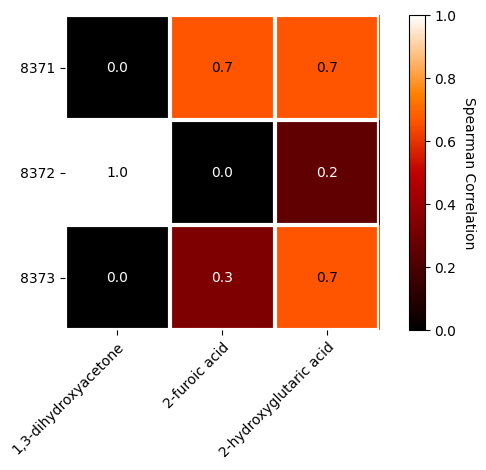

In [10]:
fpath_fig = os.path.join(
    os.getcwd(),
    "..",
    "sample_data",
    "out",
    "rhodo_test_prot_corr_mat.png"
    )


sys.argv = [
    'valpas',
    'visualize',
    '-i', fpath_output_assoc_mat_csv,
    '-t', 'heatmap',
    '-c', 'Spearman Correlation',
    '-o', fpath_fig
]
valpas_main()